### Start

In [4]:
import os 
import numpy as np
from datetime import date
import matplotlib.pyplot as plt 
import pandas as pd 


In [5]:
def getrmse(y,x):
    return np.sqrt(np.sum(np.square(y-x))/len(y))

def getmae(y,x):
    return np.sum(np.abs(y-x))/len(y)

def getbias(y,x):
    """
    y: 真值，
    x: 估计值
    """
    return np.sum(x-y)/len(y)

def getunRMSE(y,x):
    t1 = (x-np.mean(x))
    t2 = (y-np.mean(y))
    return np.sqrt(np.sum(np.square(t1-t2))/len(y))

def getR(y,x):
    return np.corrcoef(y,x)[1,0]


In [6]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 1000)   # 或 1000
pd.set_option("display.max_colwidth", None)


#### 针对Grid Extract结果，对每个观测网，先得到每个pixel上的值，整理为csv

In [14]:
rootPath = 'E:/SM_results_7_dielectric_model/Results/Site_Extract_Inv_withSMAP_AG_withCoarseSoil_BestModel_newWang/'
os.chdir(rootPath)
networks = []
for file in os.listdir(rootPath):
    s = pd.read_csv(file)
    s['Network'] = s['Network'].astype('str')
    t = s['Network'].iloc[0]
    networks.append(t)
networks = set(networks)
networks = list(networks)
networks = sorted(networks)
print(s.columns)


Index(['Network', 'Station', 'Lon', 'Lat', 'rowID', 'colID', 'Dem', 'Clay',
       'Sand', 'Silt', 'SOM', 'Bulk', 'ECe', 'LC', 'Date', 'NDVI', 'SM_Obs',
       'ST', 'TBv', 'VOD', 'SMS_Dob', 'SMS_Wang', 'SMS_Mir09', 'SMS_Mir13',
       'SMS_Mir19', 'SMS_Park', 'SMG_Dob', 'SMG_Wang', 'SMG_Mir09',
       'SMG_Mir13', 'SMG_Mir19', 'SMG_Park', 'SMG_Top', 'SMG_SCV', 'SMG_SCH',
       'SMG_DCA', 'ASCAT', 'GLDAS', 'Clay_Coarse', 'Sand_Coarse',
       'Silt_Coarse', 'SOM_Coarse', 'Bulk_Coarse', 'bestModel'],
      dtype='object')


In [16]:
rootPath = 'E:/SM_results_7_dielectric_model/Results/Site_Extract_Inv_withSMAP_AG_withCoarseSoil_BestModel_newWang/'
savePath = 'E:/SM_results_7_dielectric_model/Results/Grid_Extract_Inv_withSMAP_withCoarseSoil/'
if not os.path.exists(savePath):
    os.makedirs(savePath)

os.chdir(rootPath)
files = os.listdir(rootPath)
for net in networks:
    file_sets = [file for file in files if file.split('+')[0] == net]
    tmp = pd.concat([pd.read_csv(i) for i in file_sets])
    tmp['IDX'] = tmp['rowID'].astype(str) + '-' + tmp['colID'].astype(str)
    lc_mode = (tmp.groupby('IDX')['LC'].agg(lambda s: s.mode(dropna=True).iloc[0] if not s.mode(dropna=True).empty else pd.NA).rename('LC').reset_index())
    tmp = tmp.groupby(['IDX','Date'])[['Clay','Sand','Silt','SOM','ECe','Clay_Coarse','Sand_Coarse','Silt_Coarse','SOM_Coarse','NDVI','ST','VOD','SM_Obs','SMG_Dob','SMG_Wang','SMG_Mir09','SMG_Mir13','SMG_Mir19','SMG_Park','SMG_Top','SMG_SCV','SMG_SCH','SMG_DCA']].mean().reset_index()
    tmp = tmp.merge(lc_mode, on='IDX', how='left')
    tmp['Network'] = net
    for idx in tmp['IDX'].unique().tolist():
        s = tmp.loc[tmp['IDX']==idx].sort_values('Date')
        s[['Network','IDX','Clay','Sand','Silt','SOM','ECe','Clay_Coarse','Sand_Coarse','Silt_Coarse','SOM_Coarse','LC','Date','ST','VOD','NDVI','SM_Obs','SMG_Dob','SMG_Wang','SMG_Mir09','SMG_Mir13','SMG_Mir19','SMG_Park','SMG_Top','SMG_SCV','SMG_SCH','SMG_DCA']].dropna().to_csv(os.path.join(savePath,net+'+'+idx+'.csv'),index=False)

#### 针对每个站点进行ANOVA分析

##### 每个站点使用逐日数据计算ANOVA

把 Date 作为日期效应，表示当天辐射亮温观测误差、降水变异等诸多外部因素的影响，介电模型作为因子：

𝑒𝑟𝑟𝑜𝑟=𝜇+Model+Date+𝜀


用平方和 SS 分解后，介电模型贡献可用 η²（eta squared）：

总体贡献（η²）：𝜂2=SSTotal/SSModel
​

偏“控制站点后的贡献”（partial η²）：𝜂𝑝2=𝑆𝑆Model/(𝑆𝑆Model+𝑆𝑆Residual)

In [25]:
from scipy.stats import f

def anova_eta_station_csv(
    csv_path,
    date_col="Date",
    obs_col="SM_Obs",
    network_col="Network",
    rc_col="IDX",
    model_cols=['SMG_Dob','SMG_Wang','SMG_Mir09','SMG_Mir13','SMG_Top','SMG_Mir19','SMG_Park'],
    soil_cols=["Clay", "Sand", "Silt", "SOM", "ECe", "LC"],
    dyn_cols=None,                 # 例如 ["NDVI","ST","TBH","TBV","VOD"]
    dyn_prefix="mean_",            # 输出字段前缀
    dyn_mean_on_filtered=True,     # True: 在“有效配对日期”上取均值；False: 在原始df上对该列自身dropna后取均值
):
    """
    单站点/单grid：raw误差的 model×date(无重复) RM-ANOVA（date作block）。
    输出：
      - eta, partial_eta, F, p
      - spread_sm_mean（= spread_error_mean，原因：std(x-c)=std(x)）
      - soil_cols（常量属性，取首行）
      - dyn_cols 的均值（每天变化的变量，输出 mean_<col>）
    """

    df0 = pd.read_csv(csv_path)

    network = df0[network_col].iloc[0] if network_col in df0.columns else os.path.basename(csv_path)
    rowcol  = df0[rc_col].iloc[0] if rc_col in df0.columns else os.path.basename(csv_path)

    # 必要列检查
    need_cols = [date_col, obs_col] + list(model_cols)
    missing = [c for c in need_cols if c not in df0.columns]
    if missing:
        raise ValueError(f"Missing columns in {csv_path}: {missing}")

    # 只保留“观测与所有模型都有值”的日期（保证配对/重复测量）
    df = df0.dropna(subset=need_cols).copy()
    df = df.sort_values(date_col).reset_index(drop=True)

    T = len(df)
    M = len(model_cols)

    # ===== 动态变量均值：在筛选后的df 或 原始df上计算 =====
    out = {"Network": network, "IDX": rowcol, "n_dates": int(T)}

    if dyn_cols:
        if dyn_mean_on_filtered:
            dfor = df
        else:
            dfor = df0

        for c in dyn_cols:
            if c in dfor.columns:
                vals = pd.to_numeric(dfor[c], errors="coerce").to_numpy(dtype=float)
                out[f"{dyn_prefix}{c}"] = float(np.nanmean(vals)) if np.isfinite(np.nanmean(vals)) else np.nan
            else:
                out[f"{dyn_prefix}{c}"] = np.nan

    # ===== 土壤/LC 等常量属性 =====
    for c in soil_cols:
        out[c] = df0[c].iloc[0] if c in df0.columns else np.nan

    # 数据不足以做RM-ANOVA
    if T < 2 or M < 2:
        out.update({
            "eta": np.nan, "partial_eta": np.nan,
            "F": np.nan, "p": np.nan,
            "spread_sm_mean": np.nan,
            'bias_sm_mean': np.nan,
        })
        return out

    # ===== 反演SM矩阵 & 误差矩阵 =====
    SM_mat = np.vstack([pd.to_numeric(df[c], errors="coerce").to_numpy(dtype=float) for c in model_cols])  # (M,T)
    obs = pd.to_numeric(df[obs_col], errors="coerce").to_numpy(dtype=float)                                # (T,)
    ERR_mat = SM_mat - obs                                                                               # (M,T)

    # ===== 每日跨模型 spread（std across models，ddof=1 => N-1）=====
    # 注意：std(SM) 与 std(SM-obs) 完全相同，所以只保留一个即可
    spread_sm_t = np.std(SM_mat, axis=0, ddof=1)
    out["spread_mean"] = float(np.mean(spread_sm_t))

    from itertools import combinations
    pairs = list(combinations(range(M), 2))
    pair_abs_diff = np.array([
        np.abs(SM_mat[i] - SM_mat[j]) for i, j in pairs
    ])  # (n_pairs, T)

    bias_sm_t = np.mean(pair_abs_diff, axis=0)
    out["bias_sm_mean"] = float(np.mean(bias_sm_t))

    # ===== RM-ANOVA：用误差矩阵做分解 =====
    E = ERR_mat

    grand  = E.mean()
    mean_m = E.mean(axis=1, keepdims=True)  # (M,1)
    mean_t = E.mean(axis=0, keepdims=True)  # (1,T)

    SS_model = T * np.sum((mean_m.flatten() - grand) ** 2)
    SS_date  = M * np.sum((mean_t.flatten() - grand) ** 2)
    resid    = E - mean_m - mean_t + grand
    SS_res   = np.sum(resid ** 2)
    SS_total = SS_model + SS_date + SS_res

    eta2 = SS_model / SS_total if SS_total > 0 else np.nan
    partial_eta2 = SS_model / (SS_model + SS_res) if (SS_model + SS_res) > 0 else np.nan

    # F检验
    df_model = M - 1
    df_res   = (M - 1) * (T - 1)
    MS_model = SS_model / df_model if df_model > 0 else np.nan
    MS_res   = SS_res / df_res if df_res > 0 else np.nan
    F_stat   = MS_model / MS_res if (np.isfinite(MS_model) and np.isfinite(MS_res) and MS_res > 0) else np.nan
    p_value  = f.sf(F_stat, df_model, df_res) if np.isfinite(F_stat) else np.nan

    out.update({
        "eta": float(eta2) if np.isfinite(eta2) else np.nan,
        "partial_eta": float(partial_eta2) if np.isfinite(partial_eta2) else np.nan,
        #"F": float(F_stat) if np.isfinite(F_stat) else np.nan,
        "p": float(p_value) if np.isfinite(p_value) else np.nan,
    })

    return out


In [29]:
rootPath = 'E:/SM_results_7_dielectric_model/Results/Grid_Extract_Inv_withSMAP_withCoarseSoil/'
dyn_cols = ["NDVI", "ST", "VOD",'SM_Obs']
model_cols = [ 'SMG_Dob','SMG_Wang','SMG_Mir09','SMG_Mir13','SMG_Top','SMG_Mir19','SMG_Park'] #,'SMG_Mir19','SMG_Park' 'SMG_Dob','SMG_Wang','SMG_Mir09','SMG_Mir13','SMG_Top','SMG_Mir19','SMG_Park'
out = []
for file in os.listdir(rootPath):
    out.append(anova_eta_station_csv(os.path.join(rootPath,file),model_cols=model_cols,dyn_cols=dyn_cols))

res = pd.DataFrame(out)
print(res[['eta','partial_eta']].mean())
print(np.percentile(res['eta'],[25,50,75]))
#res.head()
print(res.groupby(['Network'])[['eta','partial_eta']].mean().reset_index()[['eta','partial_eta']].mean())
res.groupby(['Network'])[['eta','partial_eta']].mean().reset_index()
#res.to_csv('E:/SM_results_7_dielectric_model/Evaluation/ANOVA_grid_scale_finesoil_onlyDP.csv',index=False)

eta            0.239974
partial_eta    0.830093
dtype: float64
[0.14651156 0.22224612 0.30959239]
eta            0.248165
partial_eta    0.819796
dtype: float64


,Network,eta,partial_eta
0,AMMA-CATCH,0.128096,0.598607
1,ARM,0.287221,0.879316
2,BIEBRZA-S-1,0.086786,0.864356
3,Berlin,0.342555,0.905337
4,COSMOS-UK,0.258218,0.882078
5,CTP-SMTMN,0.295516,0.872874
6,CW3E,0.227184,0.827091
7,DAHRA,0.040411,0.273762
8,DWD,0.190479,0.815906
9,FLUXNET-AMERIFLUX,0.239198,0.779453


##### Version 2

In [19]:
import os
from itertools import combinations

import numpy as np
import pandas as pd
from scipy.stats import f, friedmanchisquare


def _nanmean_or_nan(x):
    x = np.asarray(x, dtype=float)
    return float(np.nanmean(x)) if (x.size > 0 and np.isfinite(x).any()) else np.nan


def _first_valid_or_nan(series):
    s = series.dropna()
    return s.iloc[0] if len(s) > 0 else np.nan


def _rm_anova_from_matrix(Y):
    """
    对 shape = (M, T) 的矩阵做单因素重复测量 ANOVA
    M: 模型数
    T: 日期数（block / repeated measure）
    """
    Y = np.asarray(Y, dtype=float)

    if Y.ndim != 2:
        raise ValueError("Y must be a 2D array with shape (n_models, n_dates).")
    if not np.isfinite(Y).all():
        raise ValueError("Y contains NaN or inf; please pass a complete matrix.")

    M, T = Y.shape

    if M < 2 or T < 2:
        return {
            "eta": np.nan,
            "partial_eta": np.nan,
            "F": np.nan,
            "p": np.nan,
            "SS_model": np.nan,
            "SS_date": np.nan,
            "SS_res": np.nan,
            "SS_total": np.nan,
            "df_model": np.nan,
            "df_res": np.nan,
        }

    grand = Y.mean()
    mean_m = Y.mean(axis=1, keepdims=True)   # (M, 1)
    mean_t = Y.mean(axis=0, keepdims=True)   # (1, T)

    SS_model = T * np.sum((mean_m.flatten() - grand) ** 2)
    SS_date = M * np.sum((mean_t.flatten() - grand) ** 2)
    resid = Y - mean_m - mean_t + grand
    SS_res = np.sum(resid ** 2)
    SS_total = SS_model + SS_date + SS_res

    eta2 = SS_model / SS_total if SS_total > 0 else np.nan
    partial_eta2 = SS_model / (SS_model + SS_res) if (SS_model + SS_res) > 0 else np.nan

    df_model = M - 1
    df_res = (M - 1) * (T - 1)

    MS_model = SS_model / df_model if df_model > 0 else np.nan
    MS_res = SS_res / df_res if df_res > 0 else np.nan

    if np.isfinite(MS_model) and np.isfinite(MS_res):
        if MS_res > 0:
            F_stat = MS_model / MS_res
            p_value = f.sf(F_stat, df_model, df_res)
        else:
            if SS_model > 0:
                F_stat = np.inf
                p_value = 0.0
            else:
                F_stat = 0.0
                p_value = 1.0
    else:
        F_stat = np.nan
        p_value = np.nan

    return {
        "eta": float(eta2) if np.isfinite(eta2) else np.nan,
        "partial_eta": float(partial_eta2) if np.isfinite(partial_eta2) else np.nan,
        "F": float(F_stat) if np.isfinite(F_stat) else (np.inf if F_stat == np.inf else np.nan),
        "p": float(p_value) if np.isfinite(p_value) else np.nan,
        "SS_model": float(SS_model) if np.isfinite(SS_model) else np.nan,
        "SS_date": float(SS_date) if np.isfinite(SS_date) else np.nan,
        "SS_res": float(SS_res) if np.isfinite(SS_res) else np.nan,
        "SS_total": float(SS_total) if np.isfinite(SS_total) else np.nan,
        "df_model": int(df_model),
        "df_res": int(df_res),
    }


def _friedman_from_matrix(Y):
    """
    Friedman 检验：重复测量下更稳健的非参数补充。
    scipy 要求至少 3 个 treatment。
    """
    Y = np.asarray(Y, dtype=float)

    if Y.ndim != 2:
        raise ValueError("Y must be a 2D array with shape (n_models, n_dates).")
    if not np.isfinite(Y).all():
        raise ValueError("Y contains NaN or inf; please pass a complete matrix.")

    M, T = Y.shape
    if M < 3 or T < 2:
        return {"friedman_chi2": np.nan, "friedman_p": np.nan}

    try:
        stat, p = friedmanchisquare(*[Y[i, :] for i in range(M)])
        return {
            "friedman_chi2": float(stat) if np.isfinite(stat) else np.nan,
            "friedman_p": float(p) if np.isfinite(p) else np.nan,
        }
    except Exception:
        return {"friedman_chi2": np.nan, "friedman_p": np.nan}


def _add_prefixed_stats(out, prefix, stats_dict):
    for k, v in stats_dict.items():
        out[f"{prefix}_{k}"] = v


def _compute_mean_anomaly_1d(y):
    """
    1D anomaly：减去长期均值
    """
    y = np.asarray(y, dtype=float)
    if len(y) == 0:
        return y * np.nan
    return y - np.mean(y)


def _compute_mean_anomaly_2d(Y):
    """
    对 shape=(M, T) 的矩阵逐行计算 anomaly：每个模型减去自身长期均值
    """
    Y = np.asarray(Y, dtype=float)
    if Y.ndim != 2:
        raise ValueError("Y must be 2D")
    return np.vstack([_compute_mean_anomaly_1d(Y[i, :]) for i in range(Y.shape[0])])


def anova_eta_station_csv(
    csv_path,
    date_col="Date",
    obs_col="SM_Obs",
    network_col="Network",
    rc_col="IDX",
    model_cols=("SMG_Dob", "SMG_Wang", "SMG_Mir09", "SMG_Mir13", "SMG_Top", "SMG_Mir19", "SMG_Park"),
    soil_cols=("Clay", "Sand", "Silt", "SOM", "ECe", "LC"),
    dyn_cols=None,
    dyn_prefix="mean_",
    dyn_mean_on_filtered=True,
    strict_unique_dates=True,
):
    """
    单站点 / 单 pixel：评估“不同介电常数模型选择对反演 SM 误差与 uncertainty 的影响”。

    uncertainty / anomaly 按论文定义：
        SM_anom = SM - mean(SM)
        Obs_anom = Obs - mean(Obs)
        anom_error = SM_anom - Obs_anom

    输出包括：
    1) 基础信息
       - Network, IDX
       - n_rows_raw, n_dates_raw, n_dates_valid, valid_ratio

    2) 常量属性 / 动态变量均值
       - soil_cols
       - dyn_cols -> mean_<col>

    3) 模型间分歧（原始 SM）
       - spread_sm_mean
       - pairwise_absdiff_sm_mean
       - bias_sm_mean（兼容旧名称）

    4) 模型间分歧（anomaly SM）
       - anom_spread_sm_mean
       - anom_pairwise_absdiff_sm_mean

    5) 每个模型自己的误差统计
       - bias_<model>
       - mae_<model>
       - rmse_<model>
       - ubrmse_<model>      # 基于 anomaly error，对应随机误差 / uncertainty
       - mean_sm_<model>

    6) 四套 ANOVA + Friedman
       - raw_error_*   : 基于 (SM - Obs)
       - abs_error_*   : 基于 |SM - Obs|
       - sq_error_*    : 基于 (SM - Obs)^2
       - anom_error_*  : 基于 (SM_anom - Obs_anom)
    """
    model_cols = list(model_cols)
    soil_cols = list(soil_cols)
    dyn_cols = list(dyn_cols) if dyn_cols is not None else []

    df0 = pd.read_csv(csv_path)

    network = df0[network_col].iloc[0] if (network_col in df0.columns and len(df0) > 0) else os.path.basename(csv_path)
    rowcol = df0[rc_col].iloc[0] if (rc_col in df0.columns and len(df0) > 0) else os.path.basename(csv_path)

    out = {
        "Network": network,
        "IDX": rowcol,
        "source_file": os.path.basename(csv_path),
    }

    # 必要列检查
    need_cols = [date_col, obs_col] + model_cols
    missing = [c for c in need_cols if c not in df0.columns]
    if missing:
        raise ValueError(f"Missing columns in {csv_path}: {missing}")

    out["n_rows_raw"] = int(len(df0))

    # 日期处理
    df0 = df0.copy()
    df0[date_col] = pd.to_datetime(df0[date_col], errors="coerce")
    out["n_bad_date"] = int(df0[date_col].isna().sum())

    df0 = df0.dropna(subset=[date_col]).copy()
    df0 = df0.sort_values(date_col).reset_index(drop=True)
    out["n_dates_raw"] = int(df0[date_col].nunique()) if len(df0) > 0 else 0

    # 单 pixel / 单站点：每个日期应只有一条记录
    if strict_unique_dates and len(df0) > 0:
        dup_mask = df0[date_col].duplicated(keep=False)
        if dup_mask.any():
            dup_dates = (
                df0.loc[dup_mask, date_col]
                .dt.strftime("%Y-%m-%d")
                .drop_duplicates()
                .tolist()
            )
            raise ValueError(
                f"Duplicate dates found in {csv_path}. "
                f"This function assumes one row per date for one pixel/station. "
                f"Example duplicate dates: {dup_dates[:10]}"
            )

    # 数值列转 numeric
    numeric_cols = [obs_col] + model_cols + dyn_cols
    for c in numeric_cols:
        if c in df0.columns:
            df0[c] = pd.to_numeric(df0[c], errors="coerce")

    # 完整配对样本
    df = df0.dropna(subset=need_cols).copy()
    df = df.sort_values(date_col).reset_index(drop=True)

    T = len(df)
    M = len(model_cols)

    out["n_dates_valid"] = int(T)
    out["valid_ratio"] = float(T / out["n_dates_raw"]) if out["n_dates_raw"] > 0 else np.nan

    # 动态变量均值
    if dyn_cols:
        dfor = df if dyn_mean_on_filtered else df0
        for c in dyn_cols:
            out[f"{dyn_prefix}{c}"] = _nanmean_or_nan(dfor[c].to_numpy(dtype=float)) if c in dfor.columns else np.nan

    # 静态属性
    for c in soil_cols:
        out[c] = _first_valid_or_nan(df0[c]) if c in df0.columns else np.nan

    # 初始化模型级字段
    for m in model_cols:
        out[f"bias_{m}"] = np.nan
        out[f"mae_{m}"] = np.nan
        out[f"rmse_{m}"] = np.nan
        out[f"ubrmse_{m}"] = np.nan
        out[f"mean_sm_{m}"] = np.nan

    # 初始化总体字段
    out["spread_sm_mean"] = np.nan
    out["pairwise_absdiff_sm_mean"] = np.nan
    out["bias_sm_mean"] = np.nan

    out["anom_spread_sm_mean"] = np.nan
    out["anom_pairwise_absdiff_sm_mean"] = np.nan

    for prefix in ["raw_error", "abs_error", "sq_error", "anom_error"]:
        for k in [
            "eta", "partial_eta", "F", "p",
            "SS_model", "SS_date", "SS_res", "SS_total",
            "df_model", "df_res",
            "friedman_chi2", "friedman_p"
        ]:
            out[f"{prefix}_{k}"] = np.nan

    # 数据不足
    if T < 2 or M < 2:
        return out

    # 原始矩阵
    SM_mat = np.vstack([df[c].to_numpy(dtype=float) for c in model_cols])  # (M, T)
    obs = df[obs_col].to_numpy(dtype=float)                                 # (T,)

    ERR_mat = SM_mat - obs[None, :]
    ABS_mat = np.abs(ERR_mat)
    SQ_mat = ERR_mat ** 2

    # 原始 SM 的模型间 spread / 两两差
    spread_sm_t = np.std(SM_mat, axis=0, ddof=1)
    out["spread_sm_mean"] = float(np.mean(spread_sm_t)) if np.isfinite(spread_sm_t).all() else np.nan

    pairs = list(combinations(range(M), 2))
    if len(pairs) > 0:
        pair_abs_diff = np.array([np.abs(SM_mat[i] - SM_mat[j]) for i, j in pairs])
        pairwise_absdiff_sm_mean = float(np.mean(pair_abs_diff)) if np.isfinite(pair_abs_diff).all() else np.nan
        out["pairwise_absdiff_sm_mean"] = pairwise_absdiff_sm_mean
        out["bias_sm_mean"] = pairwise_absdiff_sm_mean  # 兼容旧名

    # 每个模型的 bias / MAE / RMSE
    for i, m in enumerate(model_cols):
        e = ERR_mat[i, :]
        out[f"bias_{m}"] = float(np.mean(e))
        out[f"mae_{m}"] = float(np.mean(np.abs(e)))
        out[f"rmse_{m}"] = float(np.sqrt(np.mean(e ** 2)))
        out[f"mean_sm_{m}"] = float(np.mean(SM_mat[i, :]))

    # anomaly / uncertainty：严格按论文，只减长期均值
    SM_anom_mat = _compute_mean_anomaly_2d(SM_mat)
    obs_anom = _compute_mean_anomaly_1d(obs)
    ANOM_ERR_mat = SM_anom_mat - obs_anom[None, :]

    # 每个模型的 ubRMSE
    for i, m in enumerate(model_cols):
        ae = ANOM_ERR_mat[i, :]
        out[f"ubrmse_{m}"] = float(np.sqrt(np.mean(ae ** 2)))

    # anomaly SM 的模型间 spread / 两两差
    anom_spread_t = np.std(SM_anom_mat, axis=0, ddof=1)
    out["anom_spread_sm_mean"] = float(np.mean(anom_spread_t)) if np.isfinite(anom_spread_t).all() else np.nan

    if len(pairs) > 0:
        anom_pair_abs_diff = np.array([np.abs(SM_anom_mat[i] - SM_anom_mat[j]) for i, j in pairs])
        out["anom_pairwise_absdiff_sm_mean"] = float(np.mean(anom_pair_abs_diff)) if np.isfinite(anom_pair_abs_diff).all() else np.nan

    # 四套分析
    raw_stats = _rm_anova_from_matrix(ERR_mat)
    raw_friedman = _friedman_from_matrix(ERR_mat)

    abs_stats = _rm_anova_from_matrix(ABS_mat)
    abs_friedman = _friedman_from_matrix(ABS_mat)

    sq_stats = _rm_anova_from_matrix(SQ_mat)
    sq_friedman = _friedman_from_matrix(SQ_mat)

    anom_stats = _rm_anova_from_matrix(ANOM_ERR_mat)
    anom_friedman = _friedman_from_matrix(ANOM_ERR_mat)

    _add_prefixed_stats(out, "raw_error", raw_stats)
    _add_prefixed_stats(out, "raw_error", raw_friedman)

    _add_prefixed_stats(out, "abs_error", abs_stats)
    _add_prefixed_stats(out, "abs_error", abs_friedman)

    _add_prefixed_stats(out, "sq_error", sq_stats)
    _add_prefixed_stats(out, "sq_error", sq_friedman)

    _add_prefixed_stats(out, "anom_error", anom_stats)
    _add_prefixed_stats(out, "anom_error", anom_friedman)

    return out


In [21]:
rootPath = 'E:/SM_results_7_dielectric_model/Results/Grid_Extract_Inv_withSMAP_withCoarseSoil/'
dyn_cols = ["NDVI", "ST", "VOD",'SM_Obs']
model_cols = ['SMG_Dob','SMG_Wang','SMG_Mir09','SMG_Mir13','SMG_Top','SMG_Mir19','SMG_Park'] #,'SMG_Mir19','SMG_Park' 'SMG_Dob','SMG_Wang','SMG_Mir09','SMG_Mir13','SMG_Top','SMG_Mir19','SMG_Park'
out = []
for file in os.listdir(rootPath):
    out.append(anova_eta_station_csv(os.path.join(rootPath,file),model_cols=model_cols,dyn_cols=dyn_cols))

res = pd.DataFrame(out)
res.head()

#res.to_csv('E:/SM_results_7_dielectric_model/Evaluation/ANOVA_grid_scale_finesoil_onlyDP.csv',index=False)

,Network,IDX,source_file,n_rows_raw,n_bad_date,n_dates_raw,n_dates_valid,valid_ratio,mean_NDVI,mean_ST,mean_VOD,mean_SM_Obs,Clay,Sand,Silt,SOM,ECe,LC,bias_SMG_Dob,mae_SMG_Dob,rmse_SMG_Dob,ubrmse_SMG_Dob,mean_sm_SMG_Dob,bias_SMG_Wang,mae_SMG_Wang,rmse_SMG_Wang,ubrmse_SMG_Wang,mean_sm_SMG_Wang,bias_SMG_Mir09,mae_SMG_Mir09,rmse_SMG_Mir09,ubrmse_SMG_Mir09,mean_sm_SMG_Mir09,bias_SMG_Mir13,mae_SMG_Mir13,rmse_SMG_Mir13,ubrmse_SMG_Mir13,mean_sm_SMG_Mir13,bias_SMG_Top,mae_SMG_Top,rmse_SMG_Top,ubrmse_SMG_Top,mean_sm_SMG_Top,bias_SMG_Mir19,mae_SMG_Mir19,rmse_SMG_Mir19,ubrmse_SMG_Mir19,mean_sm_SMG_Mir19,bias_SMG_Park,mae_SMG_Park,rmse_SMG_Park,ubrmse_SMG_Park,mean_sm_SMG_Park,spread_sm_mean,pairwise_absdiff_sm_mean,bias_sm_mean,anom_spread_sm_mean,anom_pairwise_absdiff_sm_mean,raw_error_eta,raw_error_partial_eta,raw_error_F,raw_error_p,raw_error_SS_model,raw_error_SS_date,raw_error_SS_res,raw_error_SS_total,raw_error_df_model,raw_error_df_res,raw_error_friedman_chi2,raw_error_friedman_p,abs_error_eta,abs_error_partial_eta,abs_error_F,abs_error_p,abs_error_SS_model,abs_error_SS_date,abs_error_SS_res,abs_error_SS_total,abs_error_df_model,abs_error_df_res,abs_error_friedman_chi2,abs_error_friedman_p,sq_error_eta,sq_error_partial_eta,sq_error_F,sq_error_p,sq_error_SS_model,sq_error_SS_date,sq_error_SS_res,sq_error_SS_total,sq_error_df_model,sq_error_df_res,sq_error_friedman_chi2,sq_error_friedman_p,anom_error_eta,anom_error_partial_eta,anom_error_F,anom_error_p,anom_error_SS_model,anom_error_SS_date,anom_error_SS_res,anom_error_SS_total,anom_error_df_model,anom_error_df_res,anom_error_friedman_chi2,anom_error_friedman_p
0,AMMA-CATCH,156-490,AMMA-CATCH+156-490.csv,503,0,503,503,1.0,0.178931,304.920799,0.091806,0.037481,10.966781,78.124405,10.976408,0.377988,1.120333,10.0,-0.005897,0.017720,0.026596,0.025934,0.031584,0.017769,0.021635,0.036112,0.031437,0.055250,0.020574,0.022948,0.037595,0.031466,0.058056,0.020636,0.023115,0.038489,0.032489,0.058117,0.021775,0.024093,0.041601,0.035447,0.059256,0.035642,0.036798,0.062249,0.051035,0.073123,0.010338,0.017006,0.028121,0.026151,0.047819,0.013599,0.015594,0.015594,0.014039,0.016337,0.104711,0.378382,305.569569,1.815901e-306,0.485435,3.353014,0.797489,4.635938,6,3012,1276.918914,1.074430e-272,0.034236,0.150183,88.715422,9.463493e-103,0.129025,2.909524,0.730093,3.768642,6,3012,326.969414,1.351235e-67,0.027523,0.103114,57.714355,8.118272e-68,0.003410,0.090820,0.029659,0.123889,6,3012,326.969414,1.351235e-67,1.895687e-32,9.866037e-32,4.952750e-29,1.0,7.868056e-32,3.353014,0.797489,4.150503,6,3012,318.482249,8.932914e-66
1,AMMA-CATCH,169-487,AMMA-CATCH+169-487.csv,368,0,368,368,1.0,0.416600,301.734908,0.338746,0.095430,15.136775,67.270905,17.670068,1.228711,0.074333,12.0,0.072233,0.073912,0.102305,0.072448,0.167663,0.095037,0.095450,0.107733,0.050738,0.190467,0.101893,0.102073,0.121454,0.066097,0.197323,0.102806,0.102997,0.123293,0.068059,0.198236,0.098303,0.098701,0.118881,0.066852,0.193734,0.153292,0.153489,0.175776,0.086015,0.248723,0.053398,0.056417,0.079661,0.059114,0.148829,0.032664,0.037364,0.037364,0.013692,0.015160,0.151481,0.818833,1658.750789,0.000000e+00,2.114516,11.376623,0.467839,13.958978,6,2202,1785.636248,0.000000e+00,0.147907,0.792799,1404.225386,0.000000e+00,2.000365,11.001339,0.522803,13.524507,6,2202,1661.982111,0.000000e+00,0.123329,0.526694,408.396111,0.000000e+00,0.132543,0.823064,0.119108,1.074716,6,2202,1661.982111,0.000000e+00,1.379032e-31,3.491353e-30,1.281327e-27,1.0,1.633390e-30,11.376623,0.467839,11.844462,6,2202,62.131211,1.659014e-11
2,ARM,81-220,ARM+81-220.csv,963,0,963,963,1.0,0.443394,290.127558,0.194957,0.198318,15.528735,48.379141,36.192398,1.632677,1.626000,12.0,-0.022749,0.054620,0.065656,0.061589,0.175569,-0.000695,0.039196,0.050628,0.050623,0.197623,0.005156,0.043598,0.055889,0.055651,0.203474,0.005047,0.043604,0.055902,0.055673,0.203364,-0.003149,0.044041,0.055732,0.055643,0.195169,0.052741,0.070333,0.084280,0.065738,0.251059,-0.067036,0.072527,0.083903,0.050458,

In [24]:
print(res.columns)
cols = ['raw_error_eta','abs_error_eta','sq_error_eta','anom_error_eta','raw_error_partial_eta','abs_error_partial_eta','sq_error_partial_eta','anom_error_partial_eta','spread_sm_mean','pairwise_absdiff_sm_mean']
print(res.groupby(['Network'])[cols].mean().reset_index()[cols].mean())
print(res[cols].mean())

Index(['Network', 'IDX', 'source_file', 'n_rows_raw', 'n_bad_date',
       'n_dates_raw', 'n_dates_valid', 'valid_ratio', 'mean_NDVI', 'mean_ST',
       ...
       'anom_error_F', 'anom_error_p', 'anom_error_SS_model',
       'anom_error_SS_date', 'anom_error_SS_res', 'anom_error_SS_total',
       'anom_error_df_model', 'anom_error_df_res', 'anom_error_friedman_chi2',
       'anom_error_friedman_p'],
      dtype='object', length=106)
raw_error_eta               2.481652e-01
abs_error_eta               1.888498e-01
sq_error_eta                1.808457e-01
anom_error_eta              1.435566e-31
raw_error_partial_eta       8.197958e-01
abs_error_partial_eta       4.966501e-01
sq_error_partial_eta        4.498925e-01
anom_error_partial_eta      4.336276e-30
spread_sm_mean              3.938740e-02
pairwise_absdiff_sm_mean    4.377809e-02
dtype: float64
raw_error_eta               2.399741e-01
abs_error_eta               1.570363e-01
sq_error_eta                1.432890e-01
anom_error_eta

#### 探究不同因素下的贡献差异

In [71]:
def boxplot_eta_by_level_with_stats(df, xcol, ycol="eta", n_bins=4, binning="quantile", bins=None, figsize=(14, 4)):
    d = df[[xcol, ycol]].copy()
    d = d.dropna()

    # === 分箱（最小化修改：新增 bins 参数）===
    if bins is not None:
        # bins 推荐传“边界数组”：如 [0,10,20,...]
        bins = np.asarray(bins, dtype=float)

        # 自动生成标签：0–10, 10–20...
        labels = [f"{bins[i]:g}–{bins[i+1]:g}" for i in range(len(bins)-1)]

        d["level"] = pd.cut(
            d[xcol],
            bins=bins,
            labels=labels,
            right=True,
            include_lowest=True
        )
    else:
        # 原逻辑不变
        if binning == "quantile":
            d["level"] = pd.qcut(d[xcol], q=n_bins, duplicates="drop")
        elif binning == "fixed":
            d["level"] = pd.cut(d[xcol], bins=n_bins)
        else:
            raise ValueError("binning must be 'quantile' or 'fixed'")

    # 去掉没分到箱的（例如超出bins范围）
    d = d.dropna(subset=["level"])

    # 画箱线图
    if bins is not None:
        levels = labels  # 固定分箱按labels顺序
    else:
        levels = list(d["level"].cat.categories) if hasattr(d["level"], "cat") else sorted(d["level"].unique())

    data = [d.loc[d["level"] == lv, ycol].to_numpy() for lv in levels]

    # 过滤空箱（避免画出空的bin）
    keep = [len(arr) > 0 for arr in data]
    levels = [lv for lv, k in zip(levels, keep) if k]
    data = [arr for arr, k in zip(data, keep) if k]

    plt.figure(figsize=figsize)
    plt.boxplot(data, labels=[str(lv) for lv in levels], showfliers=True)
    plt.ylabel(ycol)
    plt.xlabel(f"{xcol} levels")
    plt.title(f"Distribution of {ycol} by {xcol} level")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

    # 分组统计：count/mean/median
    stats = (d.groupby("level")[ycol]
               .agg(count="count", mean="mean", median="median")
               .reindex(levels)  # 保持与图一致的顺序
               .reset_index())
    return stats

##### 土壤质地

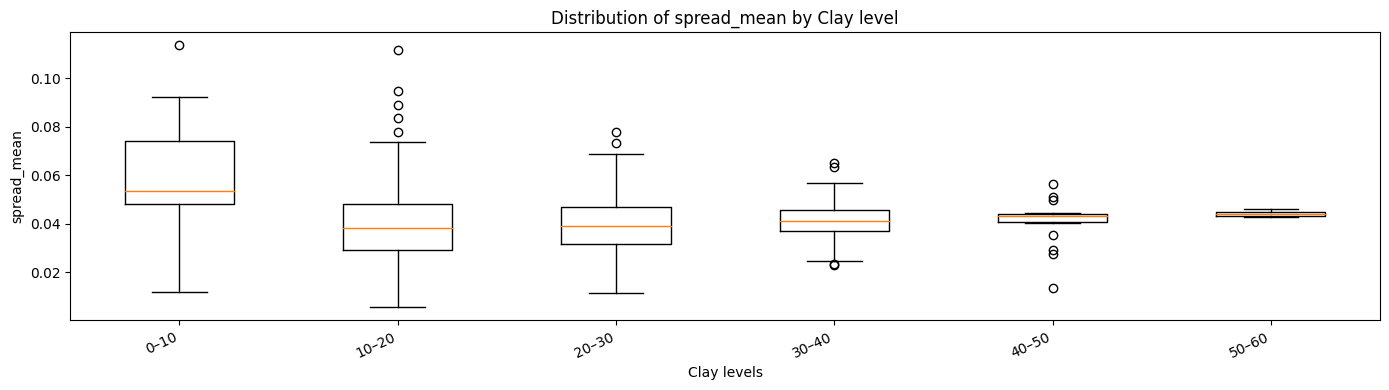

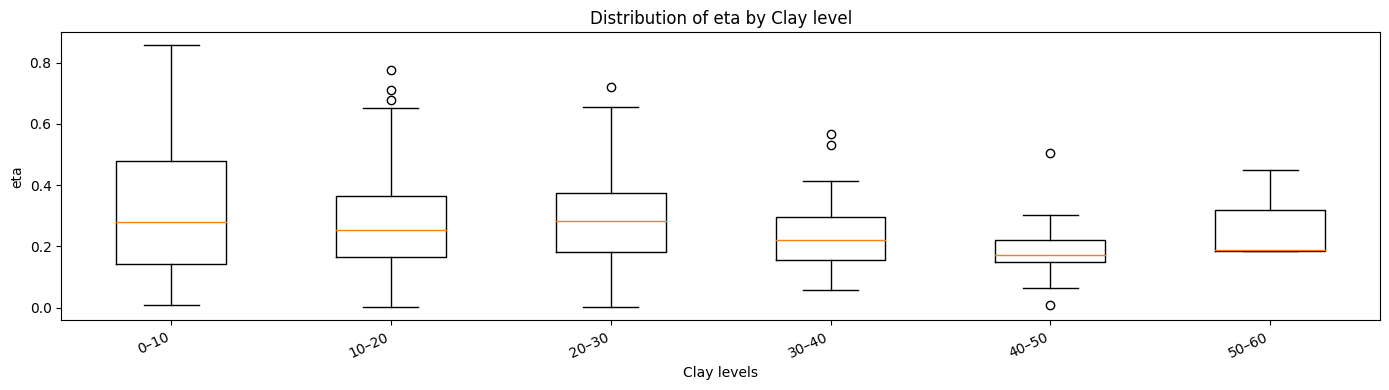

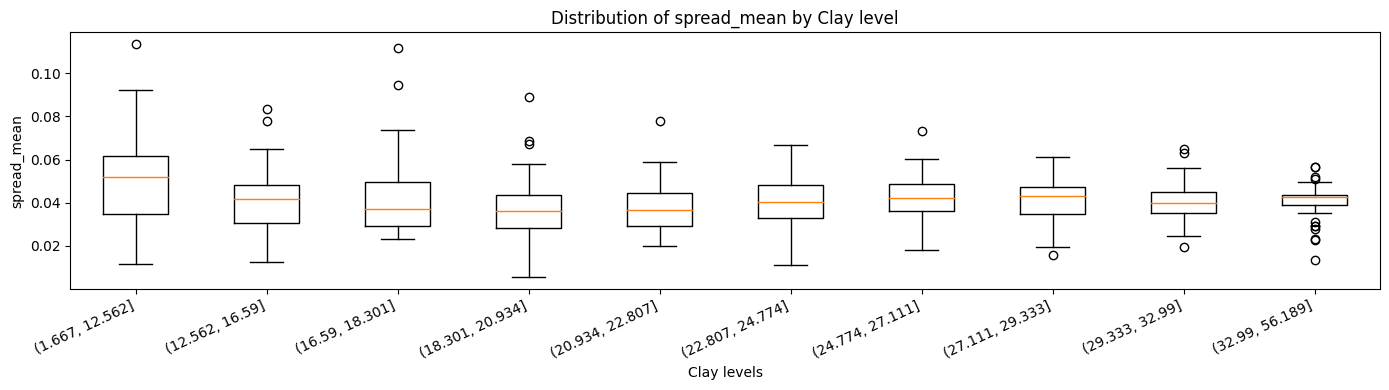

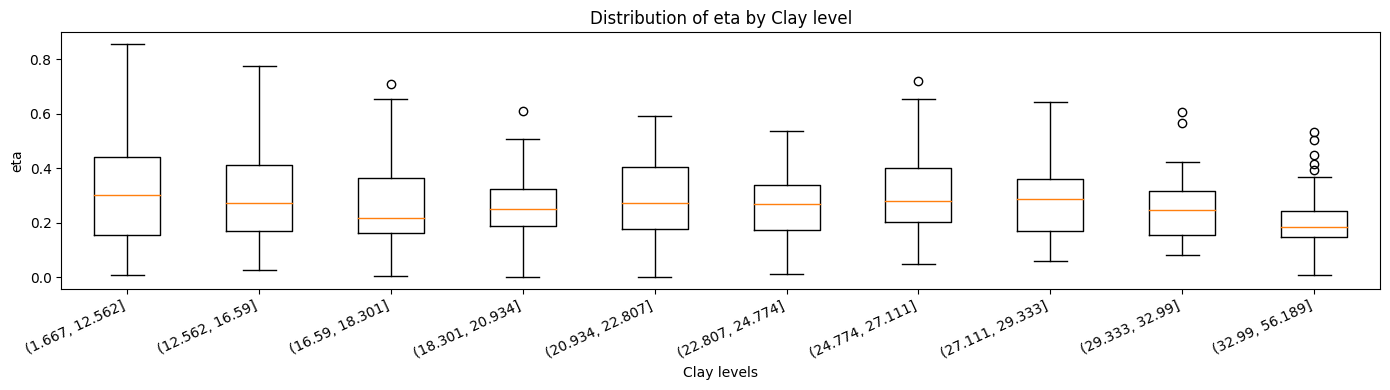

In [92]:
max_clay = res["Clay"].max()
clay_bins = np.arange(0, np.ceil(max_clay/10)*10 + 10, 10)  # 0,10,20,...覆盖最大值
stats_clay = boxplot_eta_by_level_with_stats(res, xcol="Clay", ycol="spread_mean", bins=clay_bins)
stats_clay = boxplot_eta_by_level_with_stats(res, xcol="Clay", ycol="eta", bins=clay_bins)
stats_clay = boxplot_eta_by_level_with_stats(res, xcol="Clay", ycol="spread_mean", n_bins=10, binning="quantile")
stats_clay = boxplot_eta_by_level_with_stats(res, xcol="Clay", ycol="eta", n_bins=10, binning="quantile")

##### 有机质

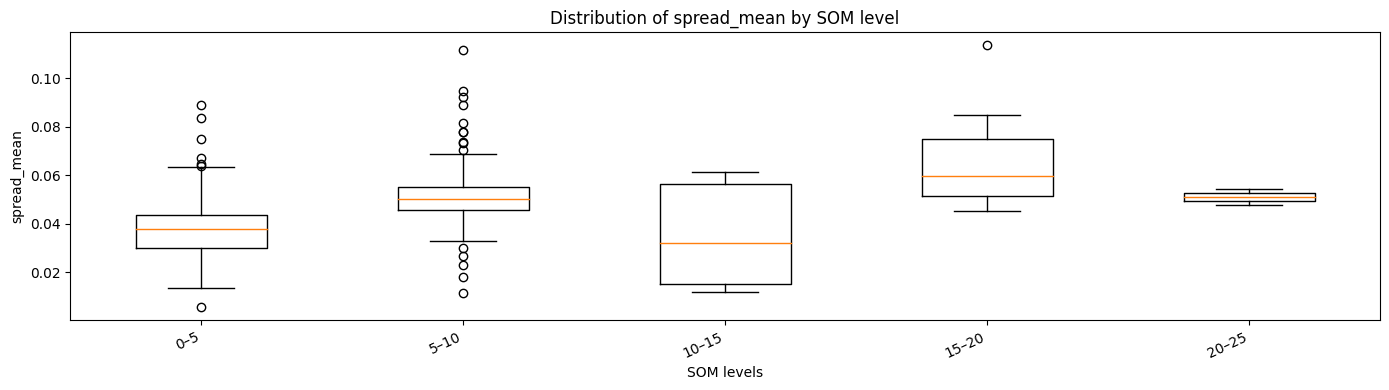

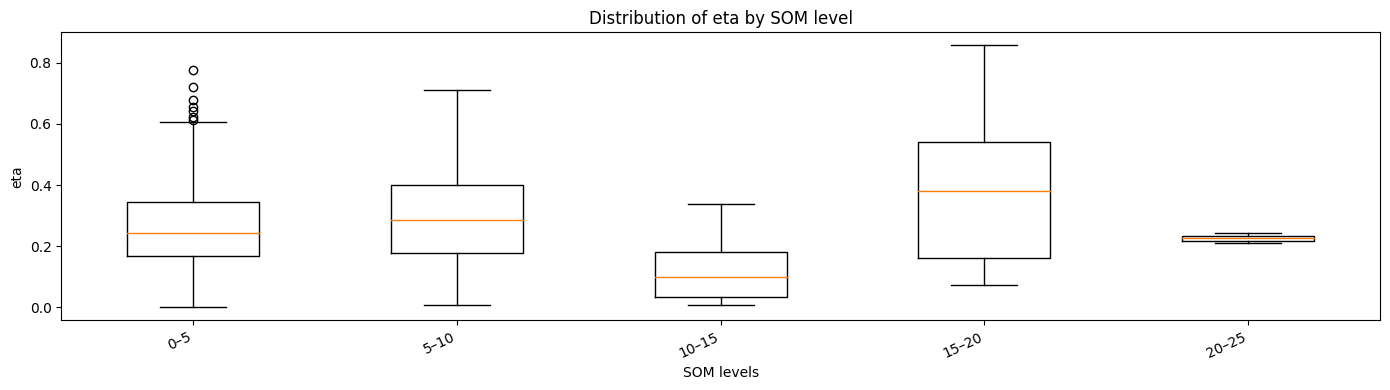

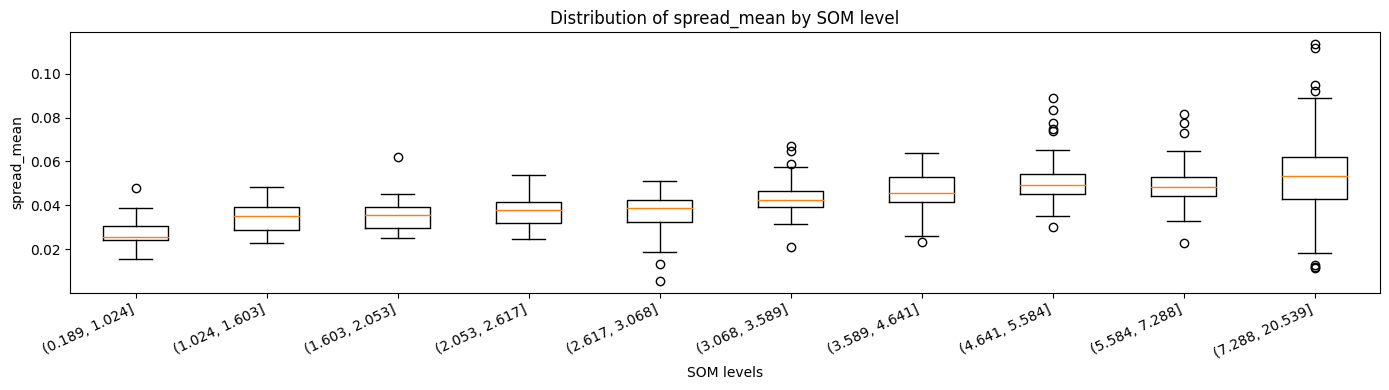

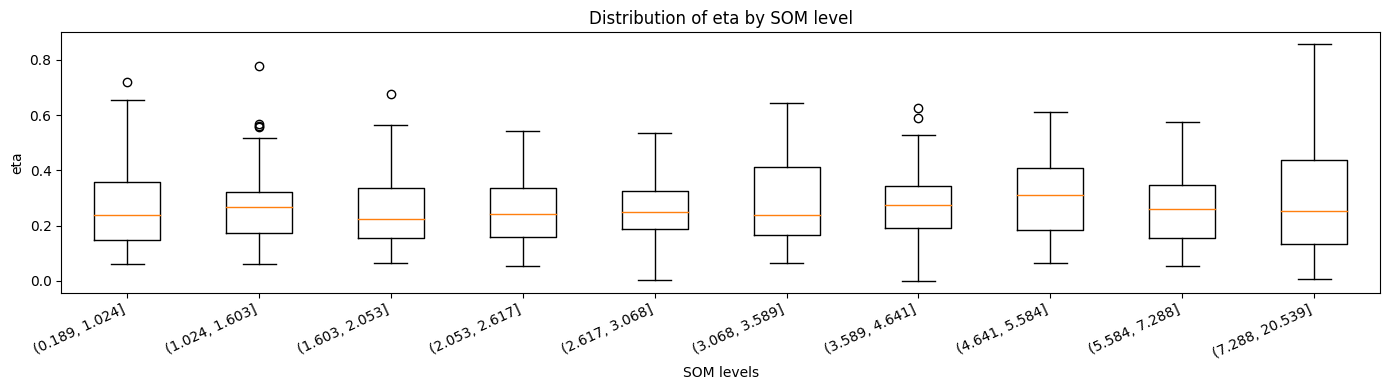

In [93]:
max_som = res["SOM"].max()
som_bins = np.arange(0, np.ceil(max_som/5)*5 + 5, 5)  # 0,10,20,...覆盖最大值
stats_som = boxplot_eta_by_level_with_stats(res, xcol="SOM", ycol="spread_mean", bins=som_bins)
stats_som = boxplot_eta_by_level_with_stats(res, xcol="SOM", ycol="eta", bins=som_bins)
stats_som = boxplot_eta_by_level_with_stats(res, xcol="SOM", ycol="spread_mean", n_bins=10, binning="quantile")
stats_som = boxplot_eta_by_level_with_stats(res, xcol="SOM", ycol="eta", n_bins=10, binning="quantile")




##### 植被

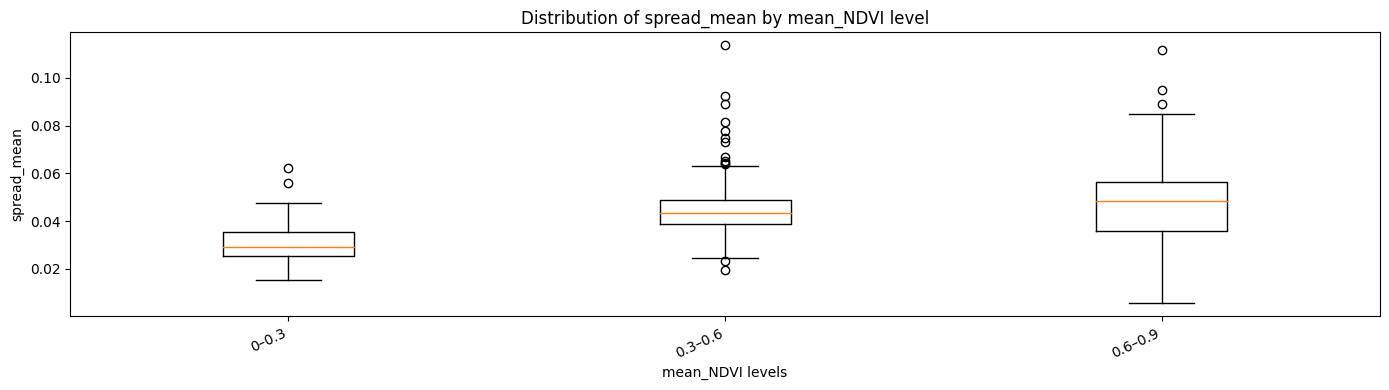

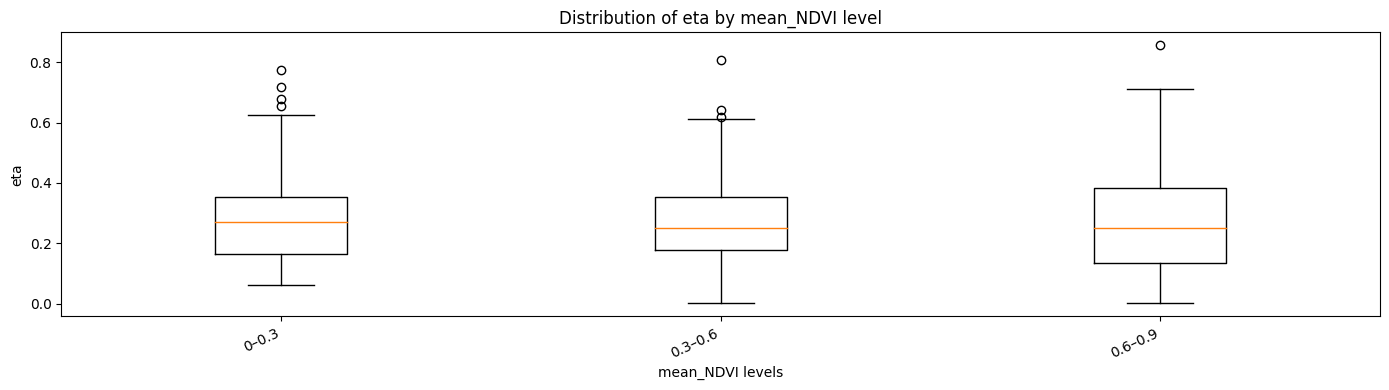

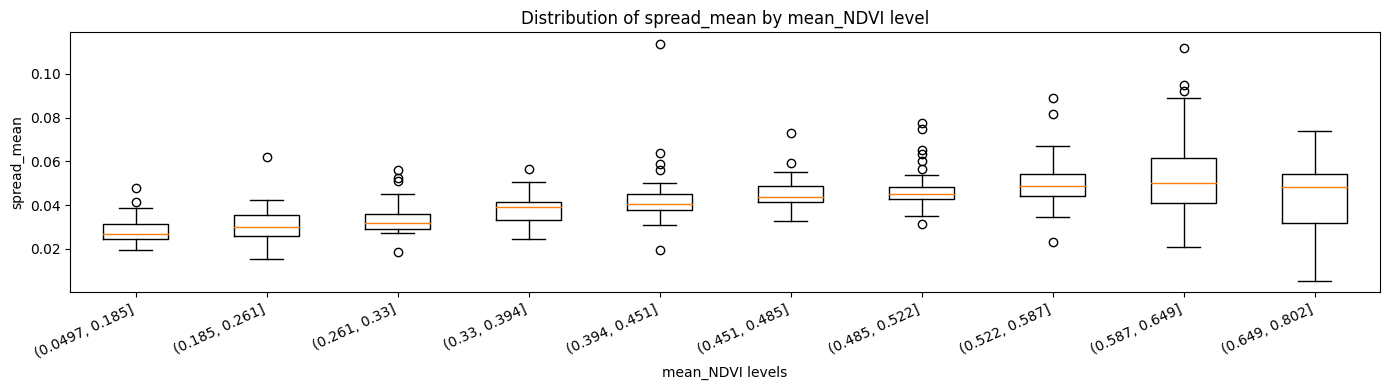

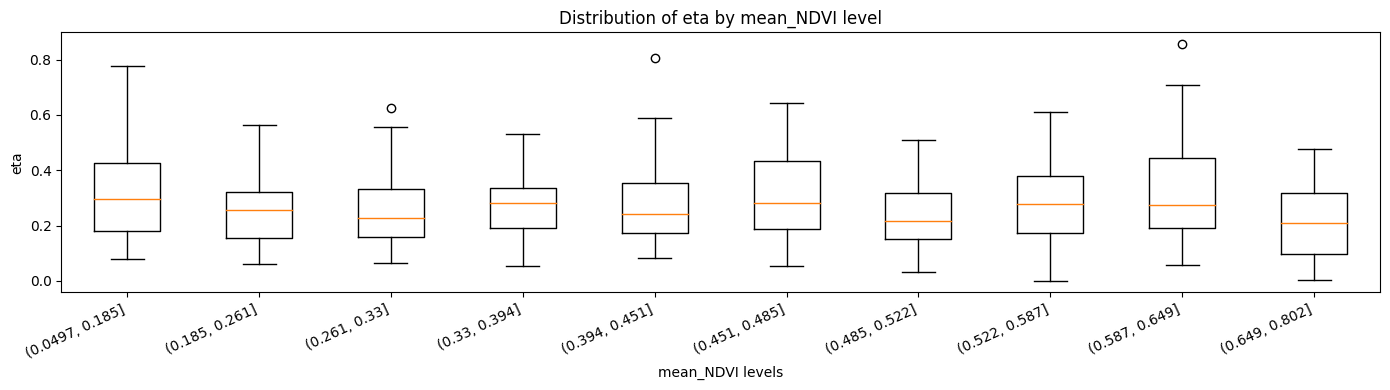

In [76]:
max_ndvi = res["mean_NDVI"].max()
ndvi_bins = np.arange(0, np.ceil(max_ndvi/0.3)*0.3 + 0.3, 0.3) 

stats_ndvi = boxplot_eta_by_level_with_stats(res, xcol="mean_NDVI", ycol="spread_mean", bins=ndvi_bins)
stats_ndvi = boxplot_eta_by_level_with_stats(res, xcol="mean_NDVI", ycol="eta", bins=ndvi_bins)
stats_ndvi = boxplot_eta_by_level_with_stats(res, xcol="mean_NDVI", ycol="spread_mean", n_bins=10, binning="quantile")
stats_ndvi = boxplot_eta_by_level_with_stats(res, xcol="mean_NDVI", ycol="eta", n_bins=10, binning="quantile")


##### 温度

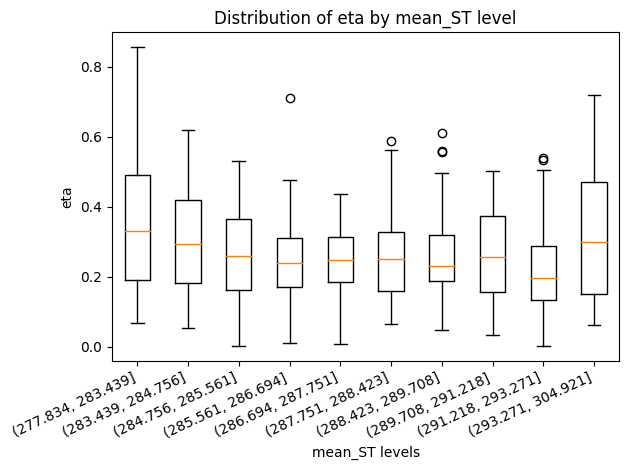

                level  count      mean    median
0  (277.834, 283.439]     42  0.361541  0.330891
1  (283.439, 284.756]     42  0.307013  0.294346
2  (284.756, 285.561]     42  0.261138  0.258533
3  (285.561, 286.694]     41  0.253849  0.237948
4  (286.694, 287.751]     42  0.247277  0.247920
5  (287.751, 288.423]     42  0.263441  0.249450
6  (288.423, 289.708]     41  0.267689  0.231579
7  (289.708, 291.218]     42  0.268662  0.255041
8  (291.218, 293.271]     42  0.212053  0.195284
9  (293.271, 304.921]     42  0.317602  0.297854


In [61]:
stats_st = boxplot_eta_by_level_with_stats(res, xcol="mean_ST", ycol="eta", n_bins=10, binning="quantile")
print(stats_st)

##### SM

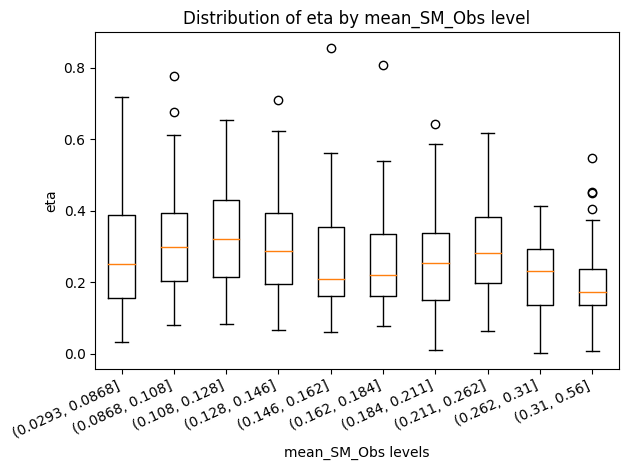

              level  count      mean    median
0  (0.0293, 0.0868]     42  0.295419  0.249782
1   (0.0868, 0.108]     42  0.320814  0.299050
2    (0.108, 0.128]     42  0.326939  0.320092
3    (0.128, 0.146]     41  0.311485  0.288304
4    (0.146, 0.162]     42  0.273622  0.207658
5    (0.162, 0.184]     42  0.267541  0.220087
6    (0.184, 0.211]     41  0.261550  0.254482
7    (0.211, 0.262]     42  0.290244  0.281941
8     (0.262, 0.31]     42  0.215235  0.232402
9      (0.31, 0.56]     42  0.198643  0.172926


In [62]:
stats_sm = boxplot_eta_by_level_with_stats(res, xcol="mean_SM_Obs", ycol="eta", n_bins=10, binning="quantile")
print(stats_sm)
